<a href="https://colab.research.google.com/github/Raditya-Z/MachineLearning_244107020144/blob/main/JS-04/JS-04_StudiKasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STUDI KASUS**

> Pada studi kasus kali ini, dilakukan proses clustering menggunakan dataset Mental Health Burnout Prediction yang didapatkan dari kaggle. Metode clustering yang digunakan adalah K-Means dan DBSCAN untuk mengelompokkan data berdasarkan karakteristik yang memiliki kemiripan. Selanjutnya, hasil dari kedua metode akan dianalisis untuk mengetahui pola pengelompokan yang terbentuk pada data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
from google.colab import files
uploaded = files.upload() # upload dataset

Saving mental_health_burnout_prediction_dataset.csv to mental_health_burnout_prediction_dataset.csv


In [26]:
df = pd.read_csv('mental_health_burnout_prediction_dataset.csv')

data_numerik = df.select_dtypes(include='number')

data_numerik.head()

,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
0,1,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,...,8.9,5.0,9.1,0.3,0.6,3,6.0,19.0,2,82
1,2,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,...,0.8,18.0,12.0,4.9,5.2,3,4.0,27.0,22,64
2,3,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,...,6.9,NaN,10.2,6.7,4.7,3,4.0,51.0,17,50
3,4,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,...,7.6,55.0,3.3,5.0,4.8,6,7.0,83.0,14,16
4,5,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,...,6.1,9.0,6.5,1.3,5.7,8,9.0,61.0,4,26


In [27]:
features = [
    'Work_Hours_Per_Week',
    'Job_Satisfaction',
    'Sleep_Hours',
    'Life_Satisfaction',
    'Depression_Score',
    'Anxiety_Score'
]

X = df[features]
X.head()

,Work_Hours_Per_Week,Job_Satisfaction,Sleep_Hours,Life_Satisfaction,Depression_Score,Anxiety_Score
0,67,3.0,4.6,6.0,75.0,74.0
1,44,5.0,4.7,4.0,80.0,58.0
2,60,8.0,6.3,4.0,55.0,54.0
3,25,2.0,7.1,7.0,11.0,12.0
4,52,1.0,9.1,9.0,48.0,25.0


Pada proses clustering dipilih enam fitur, yaitu Work_Hours_Per_Week, Job_Satisfaction, Sleep_Hours, Life_Satisfaction, Depression_Score, dan Anxiety_Score. Fitur tersebut dipilih karena dapat menggambarkan kondisi pekerjaan, kepuasan, pola tidur, serta kondisi psikologis yang relevan dengan burnout.

In [28]:
X.isnull().sum()

,0
Work_Hours_Per_Week,0
Job_Satisfaction,500
Sleep_Hours,950
Life_Satisfaction,700
Depression_Score,850
Anxiety_Score,800


In [29]:
X = df[[
    'Work_Hours_Per_Week',
    'Job_Satisfaction',
    'Sleep_Hours',
    'Life_Satisfaction',
    'Depression_Score',
    'Anxiety_Score'
]]

X = X.dropna()

print(X.shape)
print(X.isnull().sum())

(46318, 6)
Work_Hours_Per_Week    0
Job_Satisfaction       0
Sleep_Hours            0
Life_Satisfaction      0
Depression_Score       0
Anxiety_Score          0
dtype: int64


> Missing value ditangani menggunakan dropna() karena data yang hilang hanya sebesar 7,364%, sehingga masih terdapat 46.318 data atau sekitar 92,636% data yang dapat digunakan. Penghapusan juga dipilih agar proses clustering menggunakan nilai asli tanpa menambahkan nilai pengganti yang dapat memengaruhi perhitungan jarak dan pembentukan cluster.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
print(X_scaled[:5])

[[ 1.4969477  -0.87217537 -1.38572856  0.16578352  1.30937773  1.29120834]
 [-0.06399594 -0.1741216  -1.32789493 -0.53101874  1.49950026  0.6757743 ]
 [ 1.0218779   0.87295906 -0.40255673 -0.53101874  0.54888759  0.52191579]
 [-1.35347113 -1.22120225  0.06011237  0.51418465 -1.12419071 -1.09359858]
 [ 0.47894098 -1.57022914  1.21678512  1.21098691  0.28271604 -0.59355842]]


> Setelah missing value ditangani, dilakukan standardisasi menggunakan StandardScaler. Standardisasi dilakukan karena fitur yang digunakan memiliki skala nilai yang berbeda, sedangkan K-Means dan DBSCAN melakukan clustering berdasarkan perhitungan jarak. Dengan standardisasi, setiap fitur berada pada skala yang lebih sebanding sehingga tidak ada fitur dengan rentang nilai lebih besar yang terlalu mendominasi proses clustering.

# K-Means
### Menentukan k dengan Elbow Method

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

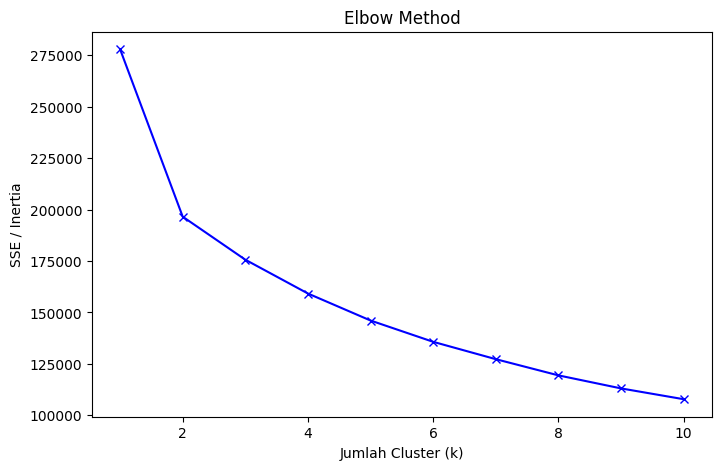

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(K, sse, 'bx-')

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method')
plt.show()

> Jumlah cluster pada K-Means ditentukan menggunakan Elbow Method. Metode ini dilakukan dengan mencoba beberapa nilai k dan menghitung nilai SSE (inertia) pada setiap jumlah cluster.

In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.3f}")

k = 2, Silhouette Score = 0.251
k = 3, Silhouette Score = 0.185
k = 4, Silhouette Score = 0.162
k = 5, Silhouette Score = 0.167
k = 6, Silhouette Score = 0.160
k = 7, Silhouette Score = 0.166
k = 8, Silhouette Score = 0.170
k = 9, Silhouette Score = 0.171
k = 10, Silhouette Score = 0.168


> Berdasarkan grafik Elbow, nilai k=2 dipertimbangkan sebagai jumlah cluster karena setelah titik tersebut penurunan SSE mulai lebih bertahap. Namun, karena titik siku pada grafik belum terlihat terlalu jelas, dilakukan evaluasi tambahan menggunakan Silhouette Score untuk membantu menentukan jumlah cluster yang lebih sesuai.

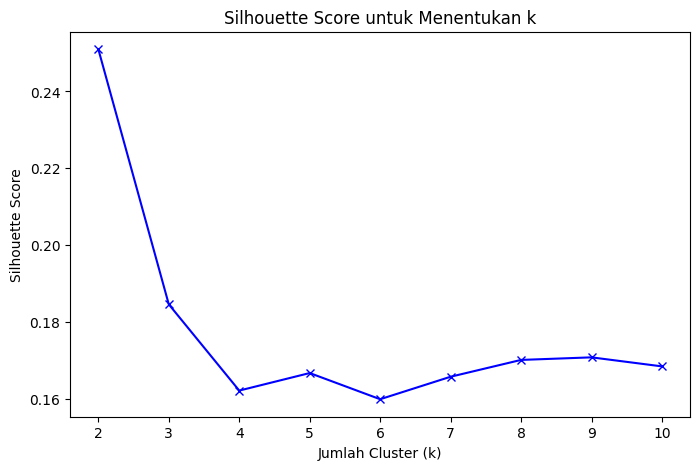

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    'bx-'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan k')
plt.show()

> Berdasarkan Elbow Method, perubahan penurunan SSE mulai terlihat melandai setelah k = 2. Hasil tersebut kemudian diperkuat dengan Silhouette Score, di mana nilai tertinggi diperoleh pada k = 2 dengan nilai sekitar 0,251. Oleh karena itu, jumlah cluster yang digunakan pada model K-Means adalah 2. Dibandingkan percobaan menggunakan empat fitur yang memperoleh Silhouette Score tertinggi sebesar 0,225, penambahan fitur Depression_Score dan Anxiety_Score meningkatkan nilai Silhouette menjadi sekitar 0,251.

In [36]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)

In [37]:
unique, counts = np.unique(labels_kmeans, return_counts=True)

for cluster, jumlah in zip(unique, counts):
    print(f"Cluster {cluster}: {jumlah} data")

Cluster 0: 24354 data
Cluster 1: 21964 data


> Setelah jumlah cluster ditentukan sebanyak 2, model K-Means dibentuk menggunakan n_clusters=2. Model kemudian melakukan pengelompokan terhadap data yang telah distandardisasi dan memberikan label cluster pada setiap data.

In [38]:
hasil_kmeans = X.copy()
hasil_kmeans['Cluster'] = labels_kmeans

hasil_kmeans.head()

,Work_Hours_Per_Week,Job_Satisfaction,Sleep_Hours,Life_Satisfaction,Depression_Score,Anxiety_Score,Cluster
0,67,3.0,4.6,6.0,75.0,74.0,1
1,44,5.0,4.7,4.0,80.0,58.0,1
2,60,8.0,6.3,4.0,55.0,54.0,1
3,25,2.0,7.1,7.0,11.0,12.0,0
4,52,1.0,9.1,9.0,48.0,25.0,0


In [39]:
cluster_summary = hasil_kmeans.groupby('Cluster').mean()

cluster_summary

,Work_Hours_Per_Week,Job_Satisfaction,Sleep_Hours,Life_Satisfaction,Depression_Score,Anxiety_Score
Cluster,,,,,,
0,35.267718,5.510429,7.309391,5.512688,20.920383,20.935698
1,55.671007,5.486068,6.648634,5.536879,62.347022,62.048261


> Berdasarkan hasil rata-rata setiap cluster, Cluster 0 memiliki jam kerja yang lebih rendah, waktu tidur yang lebih tinggi, serta skor depresi dan kecemasan yang lebih rendah. Sementara itu, Cluster 1 memiliki jam kerja yang lebih tinggi, waktu tidur yang lebih rendah, serta skor depresi dan kecemasan yang jauh lebih tinggi. Nilai Job Satisfaction dan Life Satisfaction pada kedua cluster relatif hampir sama, sehingga kedua fitur tersebut tidak menunjukkan perbedaan yang besar antarcluster.


In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

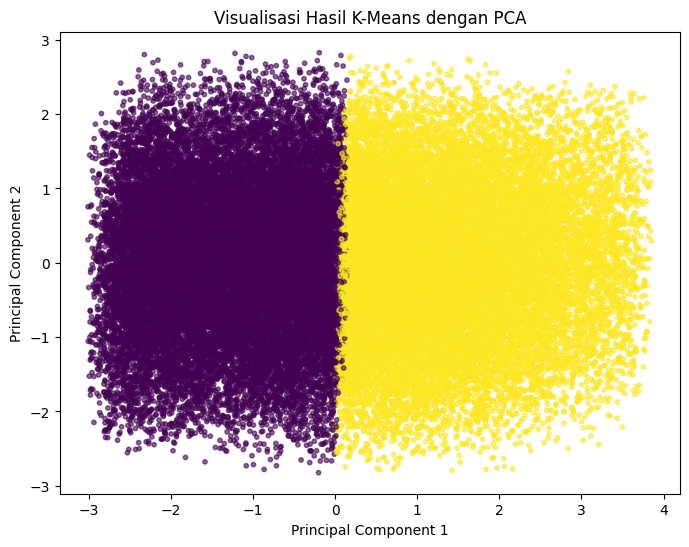

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    s=10,
    alpha=0.6
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Visualisasi Hasil K-Means dengan PCA')
plt.show()

> Karena clustering menggunakan enam fitur, visualisasi dilakukan menggunakan PCA (Principal Component Analysis). PCA digunakan untuk mereduksi enam fitur menjadi dua komponen utama sehingga hasil clustering dapat ditampilkan dalam bentuk grafik dua dimensi. PCA hanya digunakan untuk visualisasi, sedangkan proses K-Means tetap dilakukan menggunakan enam fitur yang telah distandardisasi.

# DBScan

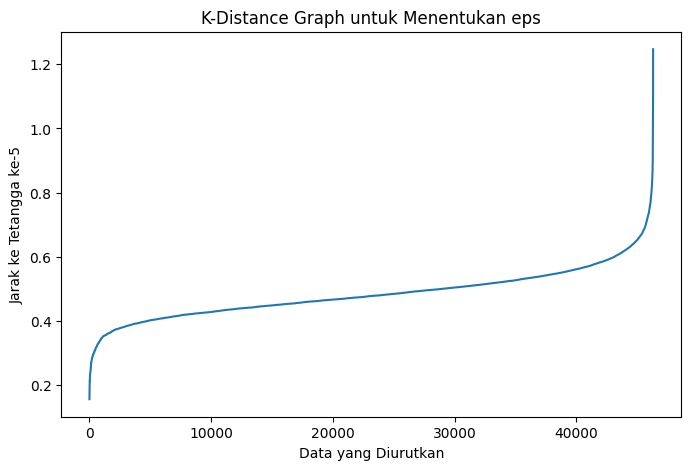

In [43]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances)

plt.xlabel('Data yang Diurutkan')
plt.ylabel('Jarak ke Tetangga ke-5')
plt.title('K-Distance Graph untuk Menentukan eps')
plt.show()

> Pada DBSCAN, jumlah cluster tidak ditentukan secara langsung seperti pada K-Means. Parameter yang perlu ditentukan adalah eps dan min_samples. Pada percobaan awal digunakan min_samples=5, sedangkan nilai eps dipertimbangkan menggunakan K-Distance Graph berdasarkan jarak ke tetangga ke-5. Titik ketika grafik mulai mengalami kenaikan yang lebih tajam digunakan sebagai kandidat nilai eps.


In [44]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)

In [45]:
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)

Jumlah cluster: 7
Jumlah noise: 773


> Berdasarkan K-Distance Graph, kenaikan jarak mulai terlihat lebih tajam pada nilai sekitar 0,6. Oleh karena itu, nilai eps=0.6 digunakan sebagai parameter awal DBSCAN dengan min_samples=5. Hasil clustering kemudian diperiksa berdasarkan jumlah cluster dan noise yang terbentuk.

In [46]:
from sklearn.metrics import silhouette_score

silhouette_dbscan = silhouette_score(X_scaled, labels_dbscan)

print(f"Silhouette Score DBSCAN: {silhouette_dbscan:.3f}")

Silhouette Score DBSCAN: -0.168


In [48]:
mask = labels_dbscan != -1

silhouette_dbscan_no_noise = silhouette_score(
    X_scaled[mask],
    labels_dbscan[mask]
)

print(
    f"Silhouette Score tanpa noise: "
    f"{silhouette_dbscan_no_noise:.3f}"
)

Silhouette Score tanpa noise: -0.164


In [50]:
eps_values = [0.5, 0.6, 0.7, 0.8]

for eps in eps_values:
    db_test = DBSCAN(
        eps=eps,
        min_samples=5
    ).fit(X_scaled)

    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    print(f"eps = {eps}")
    print(f"Jumlah cluster = {n_clusters}")
    print(f"Jumlah noise = {n_noise}")
    print()

eps = 0.5
Jumlah cluster = 116
Jumlah noise = 6667

eps = 0.6
Jumlah cluster = 7
Jumlah noise = 773

eps = 0.7
Jumlah cluster = 1
Jumlah noise = 104

eps = 0.8
Jumlah cluster = 1
Jumlah noise = 23



In [51]:
eps_values = [0.60, 0.62, 0.64, 0.66, 0.68, 0.70]

for eps in eps_values:
    db_test = DBSCAN(
        eps=eps,
        min_samples=5
    ).fit(X_scaled)

    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    print(f"eps = {eps}")
    print(f"Jumlah cluster = {n_clusters}")
    print(f"Jumlah noise = {n_noise}")
    print()

eps = 0.6
Jumlah cluster = 7
Jumlah noise = 773

eps = 0.62
Jumlah cluster = 6
Jumlah noise = 511

eps = 0.64
Jumlah cluster = 5
Jumlah noise = 332

eps = 0.66
Jumlah cluster = 3
Jumlah noise = 216

eps = 0.68
Jumlah cluster = 1
Jumlah noise = 153

eps = 0.7
Jumlah cluster = 1
Jumlah noise = 104



In [52]:
eps_values = [0.62, 0.64, 0.66]

for eps in eps_values:
    db_test = DBSCAN(
        eps=eps,
        min_samples=5
    ).fit(X_scaled)

    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    silhouette_all = silhouette_score(
        X_scaled,
        labels_test
    )

    mask = labels_test != -1

    silhouette_no_noise = silhouette_score(
        X_scaled[mask],
        labels_test[mask]
    )

    print(f"eps = {eps}")
    print(f"Jumlah cluster = {n_clusters}")
    print(f"Jumlah noise = {n_noise}")
    print(f"Silhouette = {silhouette_all:.3f}")
    print(f"Silhouette tanpa noise = {silhouette_no_noise:.3f}")
    print()


eps = 0.62
Jumlah cluster = 6
Jumlah noise = 511
Silhouette = -0.143
Silhouette tanpa noise = -0.137

eps = 0.64
Jumlah cluster = 5
Jumlah noise = 332
Silhouette = -0.208
Silhouette tanpa noise = -0.207

eps = 0.66
Jumlah cluster = 3
Jumlah noise = 216
Silhouette = -0.100
Silhouette tanpa noise = -0.092



In [53]:
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    db_test = DBSCAN(
        eps=0.66,
        min_samples=min_samples
    ).fit(X_scaled)

    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    print(f"min_samples = {min_samples}")
    print(f"Jumlah cluster = {n_clusters}")
    print(f"Jumlah noise = {n_noise}")
    print()


min_samples = 5
Jumlah cluster = 3
Jumlah noise = 216

min_samples = 10
Jumlah cluster = 1
Jumlah noise = 661

min_samples = 15
Jumlah cluster = 1
Jumlah noise = 1344

min_samples = 20
Jumlah cluster = 1
Jumlah noise = 2502



> Berdasarkan eksperimen parameter, nilai eps=0.66 dan min_samples=5 menghasilkan 3 cluster dengan 216 data noise. Nilai Silhouette yang diperoleh sebesar -0,100 dan -0,092 ketika noise tidak disertakan. Nilai negatif menunjukkan bahwa pemisahan cluster yang terbentuk masih kurang baik. Peningkatan min_samples menjadi 10, 15, dan 20 menyebabkan data cenderung bergabung menjadi satu cluster utama dan jumlah noise meningkat.

In [54]:
dbscan = DBSCAN(
    eps=0.66,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)

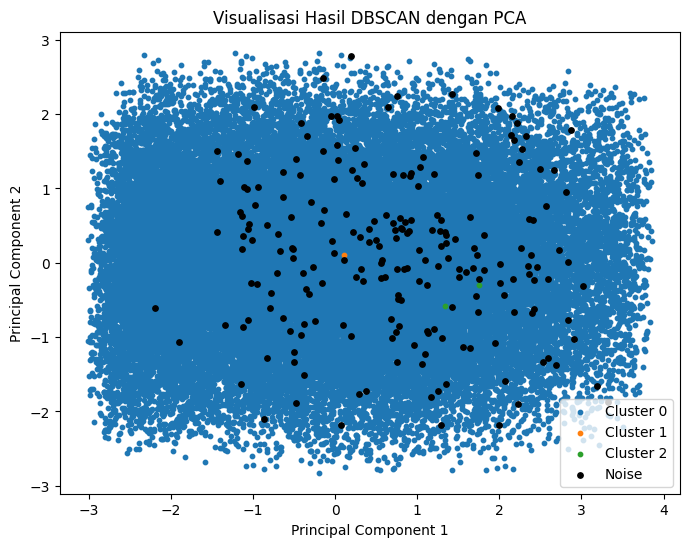

In [55]:
plt.figure(figsize=(8, 6))

unique_labels = set(labels_dbscan)

for label in unique_labels:
    mask = labels_dbscan == label

    if label == -1:
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            c='black',
            s=15,
            label='Noise'
        )
    else:
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=10,
            label=f'Cluster {label}'
        )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Visualisasi Hasil DBSCAN dengan PCA')
plt.legend()
plt.show()

> Hasil clustering DBSCAN divisualisasikan menggunakan PCA karena proses clustering menggunakan enam fitur. PCA mereduksi data menjadi dua komponen utama sehingga hasil cluster dapat ditampilkan dalam grafik dua dimensi. Pada visualisasi DBSCAN, setiap warna menunjukkan cluster yang berbeda, sedangkan titik berwarna hitam menunjukkan data yang dianggap sebagai noise.

In [56]:
unique, counts = np.unique(labels_dbscan, return_counts=True)

for label, jumlah in zip(unique, counts):
    if label == -1:
        print(f"Noise: {jumlah} data")
    else:
        print(f"Cluster {label}: {jumlah} data")


Noise: 216 data
Cluster 0: 46099 data
Cluster 1: 1 data
Cluster 2: 2 data


> Selanjutnya, jumlah anggota pada setiap cluster diperiksa untuk mengetahui distribusi data hasil DBSCAN. Pemeriksaan ini dilakukan karena pada visualisasi PCA terlihat bahwa sebagian besar data berada pada satu cluster utama, sedangkan cluster lainnya memiliki anggota yang relatif sedikit.

> Berdasarkan hasil DBSCAN dengan parameter `eps=0.66` dan `min_samples=5`, diperoleh 3 cluster dan 216 data noise. Namun, distribusi anggota cluster sangat tidak seimbang. Cluster 0 memiliki 46.099 data, sedangkan Cluster 1 hanya memiliki 1 data dan Cluster 2 memiliki 2 data.

> Hasil tersebut menunjukkan bahwa sebagian besar data dianggap berada dalam satu wilayah kepadatan yang sama. Hal ini juga didukung oleh Silhouette Score sebesar -0,100, yang menunjukkan bahwa pemisahan cluster yang terbentuk masih kurang baik. Berdasarkan eksperimen parameter yang telah dilakukan, DBSCAN belum mampu menghasilkan struktur cluster yang terpisah dengan baik pada enam fitur yang digunakan.

# **KESIMPULAN**

> Berdasarkan hasil clustering menggunakan enam fitur, yaitu `Work_Hours_Per_Week`, `Job_Satisfaction`, `Sleep_Hours`, `Life_Satisfaction`, `Depression_Score`, dan `Anxiety_Score`, K-Means dan DBSCAN menghasilkan pola pengelompokan yang berbeda.

> Pada K-Means, jumlah cluster yang digunakan adalah 2 berdasarkan hasil Elbow Method dan Silhouette Score. Nilai Silhouette Score yang diperoleh sekitar 0,251. Hasil analisis menunjukkan adanya perbedaan karakteristik antara kedua cluster, terutama pada jam kerja, waktu tidur, skor depresi, dan skor kecemasan.

> Pada DBSCAN, setelah dilakukan beberapa percobaan parameter, penggunaan `eps=0.66` dan `min_samples=5` menghasilkan 3 cluster dengan 216 data noise. Namun, distribusi cluster sangat tidak seimbang karena Cluster 0 memiliki 46.099 data, sedangkan Cluster 1 hanya memiliki 1 data dan Cluster 2 memiliki 2 data. Silhouette Score yang diperoleh sebesar -0,100.

> Berdasarkan hasil percobaan pada dataset dan konfigurasi yang digunakan, K-Means menghasilkan struktur pengelompokan yang lebih jelas dibandingkan DBSCAN. Meskipun demikian, Silhouette Score K-Means yang masih sekitar 0,251 menunjukkan bahwa pemisahan antarcluster belum terlalu kuat. Hasil ini menunjukkan bahwa karakteristik data lebih mendukung pengelompokan menggunakan pendekatan K-Means daripada pengelompokan berdasarkan kepadatan dengan DBSCAN pada parameter yang telah diuji.